# Phase 2: VIC1 Price Forecasting Baselines

Walk-forward evaluation for persistence, seasonal naive, and XGBoost on the 15-minute modeling table. All horizons come from `config/forecasting.yaml`.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

%load_ext autoreload
%autoreload 2

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config.forecasting import load_forecasting_config
from evaluation.walk_forward import run_walk_forward, summarize_results
from models.baselines import get_baseline_forecast_fn
from models.align_timeseries import region_slug

cfg = load_forecasting_config()
target_col = f"{region_slug(cfg.target_region)}_price"
print(f"Grid: {cfg.pandas_freq} | forecast_steps: {cfg.forecast_steps}")

Grid: 15min | forecast_steps: 96


In [2]:
DATA_PATH = ROOT / "data" / "processed" / "price_modeling_vic_730d.csv"
if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Missing {DATA_PATH}. Run: python src/build_price_training_table.py --days 730"
    )

df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df = df.sort_values("timestamp").reset_index(drop=True)
print(df.shape)
df[["timestamp", target_col]].head()

(70063, 83)


,timestamp,vic1_price
0,2024-06-18 00:00:00+00:00,195.500000
1,2024-06-18 00:15:00+00:00,224.566667
2,2024-06-18 00:30:00+00:00,229.056667
3,2024-06-18 00:45:00+00:00,221.006667
4,2024-06-18 01:00:00+00:00,202.010000


Missing target rows: 0
Negative prices: 17793


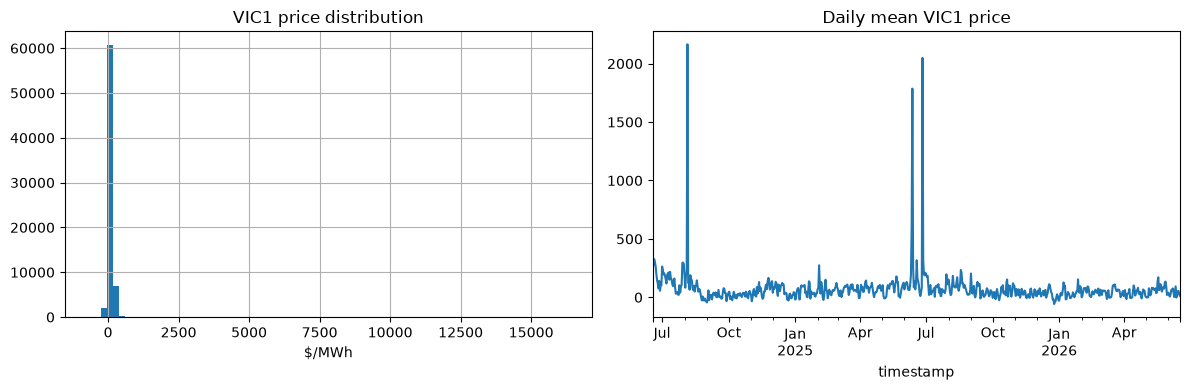

In [3]:
# EDA: price distribution and missingness
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df[target_col].hist(bins=80, ax=axes[0])
axes[0].set_title("VIC1 price distribution")
axes[0].set_xlabel("$/MWh")

daily = df.set_index("timestamp")[target_col].resample("D").mean()
daily.plot(ax=axes[1])
axes[1].set_title("Daily mean VIC1 price")
plt.tight_layout()

print("Missing target rows:", int(df[target_col].isna().sum()))
print("Negative prices:", int((df[target_col] < 0).sum()))

In [4]:
# Walk-forward baselines (selection window)
results = [
    run_walk_forward(
        df,
        target_col=target_col,
        forecast_fn=get_baseline_forecast_fn(name),
        cfg=cfg,
        model_name=name,
        split="selection",
    )
    for name in ("persistence", "seasonal_naive")
]

summary = summarize_results(results)
summary

,model,folds,mae_mean,rmse_mean
1,seasonal_naive,40,70.203279,124.407396
0,persistence,40,127.744968,173.505343


## Walk-forward: actual vs predicted over time

Chronological line plots from walk-forward folds (one prediction per timestamp, using the most recent origin). Below: a single 24-hour forecast window for detail.

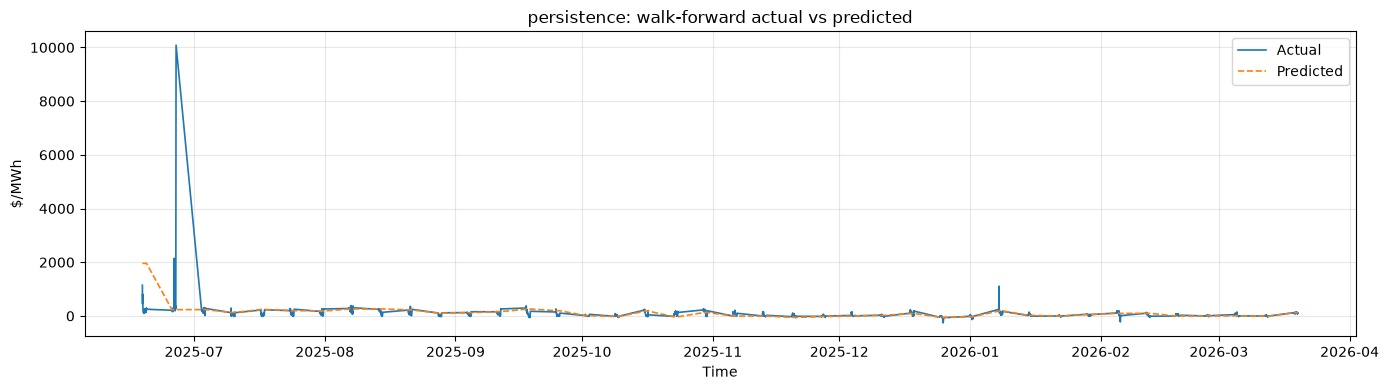

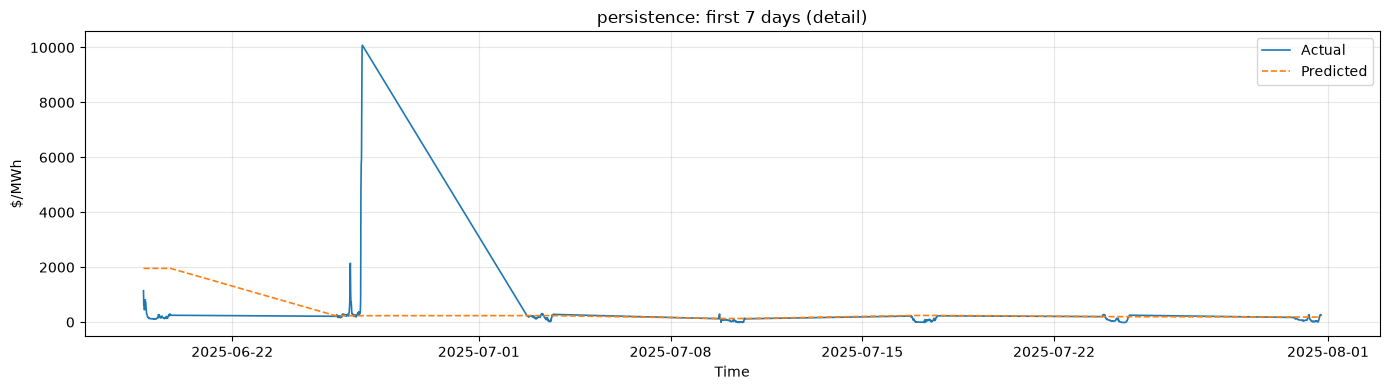

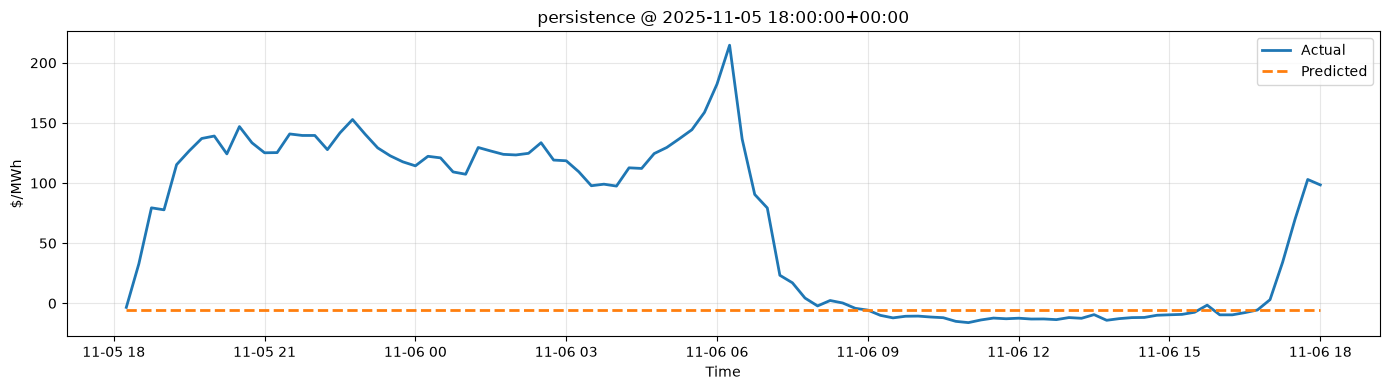

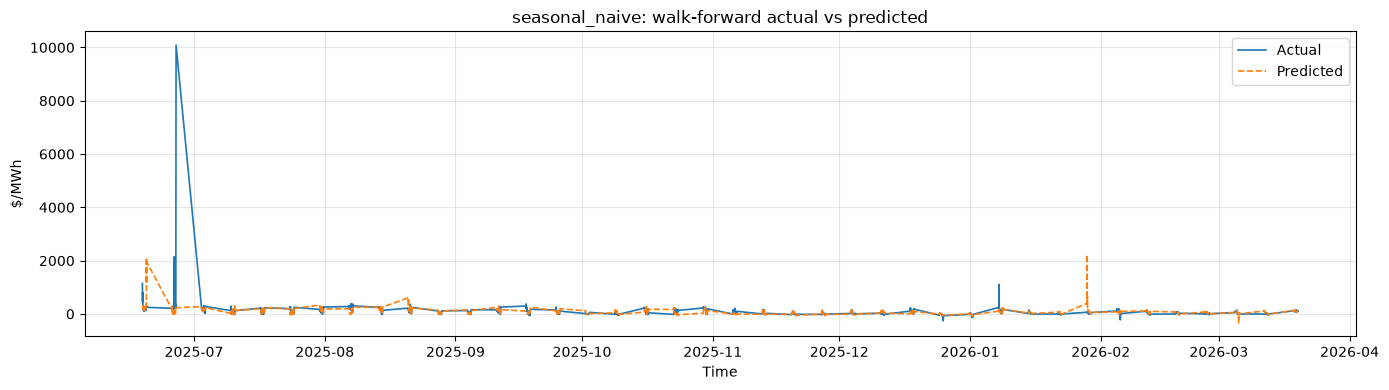

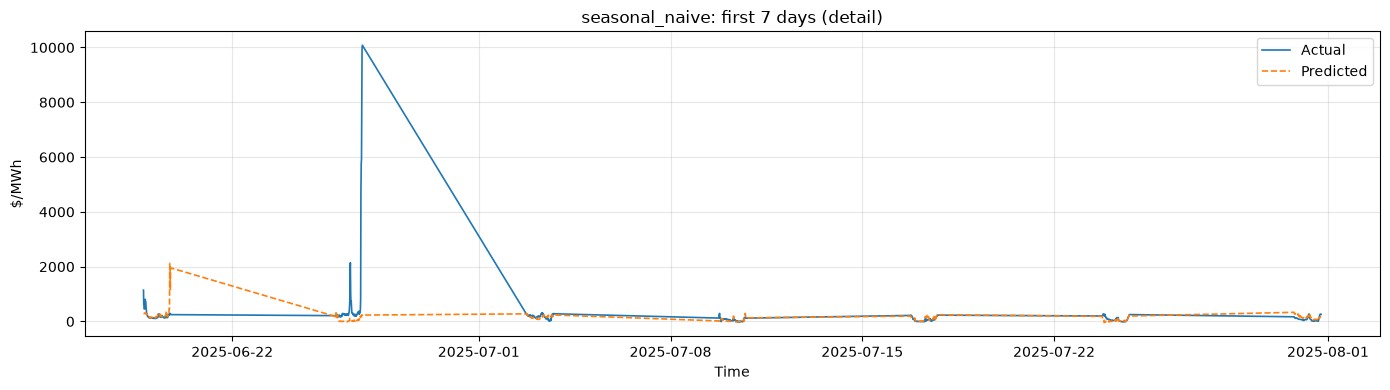

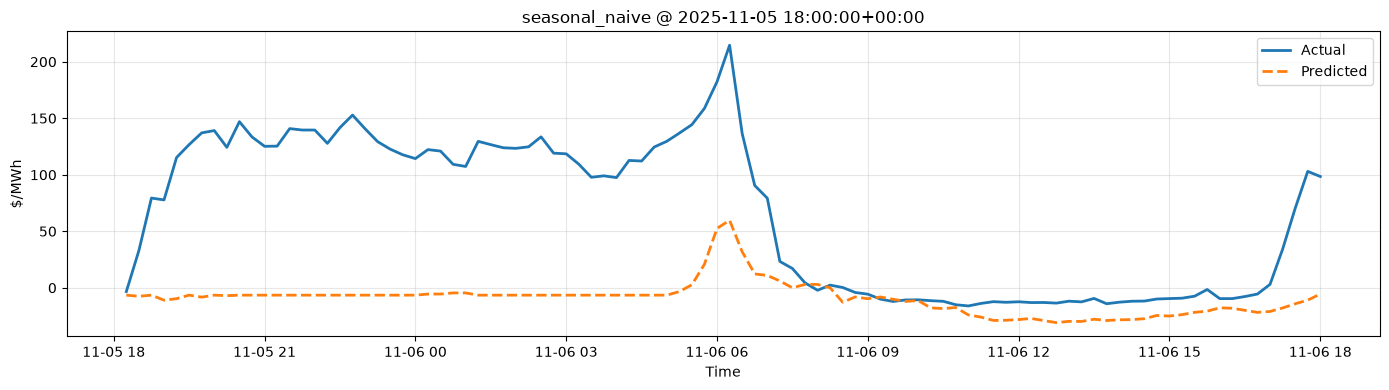

In [5]:
from evaluation.plotting import (
    plot_actual_vs_predicted_timeseries,
    plot_forecast_window,
)
from evaluation.walk_forward import (
    collect_fold_predictions,
    consolidate_walk_forward_predictions,
)

for result in results:
    pred_df = collect_fold_predictions(result)
    ts_df = consolidate_walk_forward_predictions(pred_df)

    fig, ax = plt.subplots(figsize=(14, 4))
    plot_actual_vs_predicted_timeseries(
        ts_df,
        model_name=result.model_name,
        title=f"{result.model_name}: walk-forward actual vs predicted",
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

    # Zoom: first 7 days of the consolidated series
    week = ts_df.iloc[: 96 * 7]
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_actual_vs_predicted_timeseries(
        week,
        model_name=result.model_name,
        title=f"{result.model_name}: first 7 days (detail)",
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

    sample_fold = result.folds[len(result.folds) // 2]
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_forecast_window(sample_fold, model_name=result.model_name, ax=ax)
    plt.tight_layout()
    plt.show()

XGBoost mean evaluation horizon MAE: 42.26 $/MWh


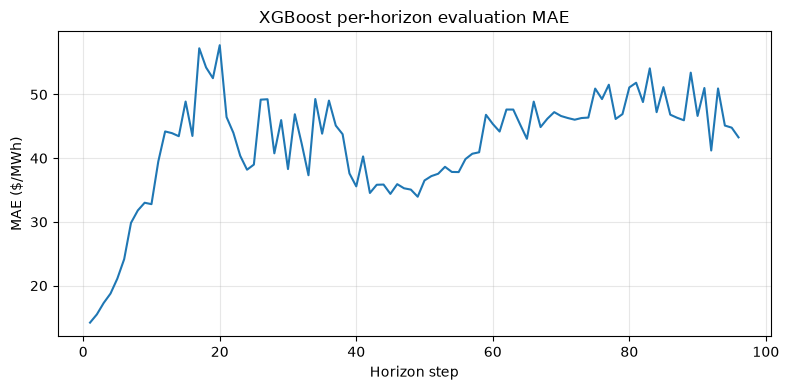

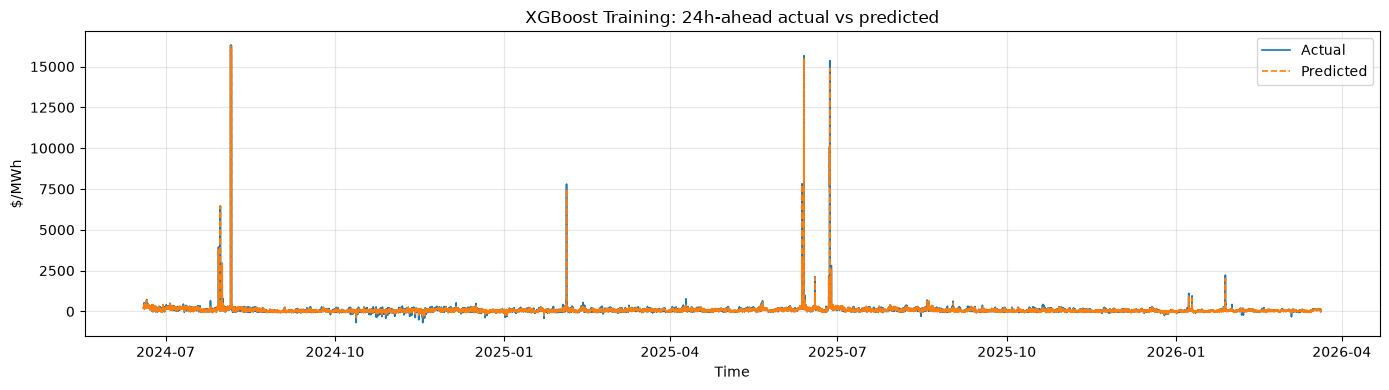

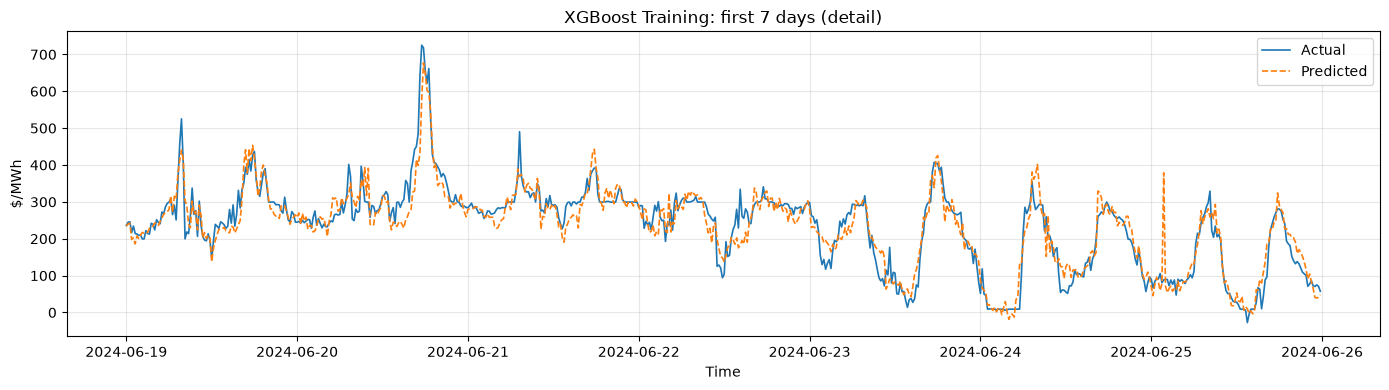

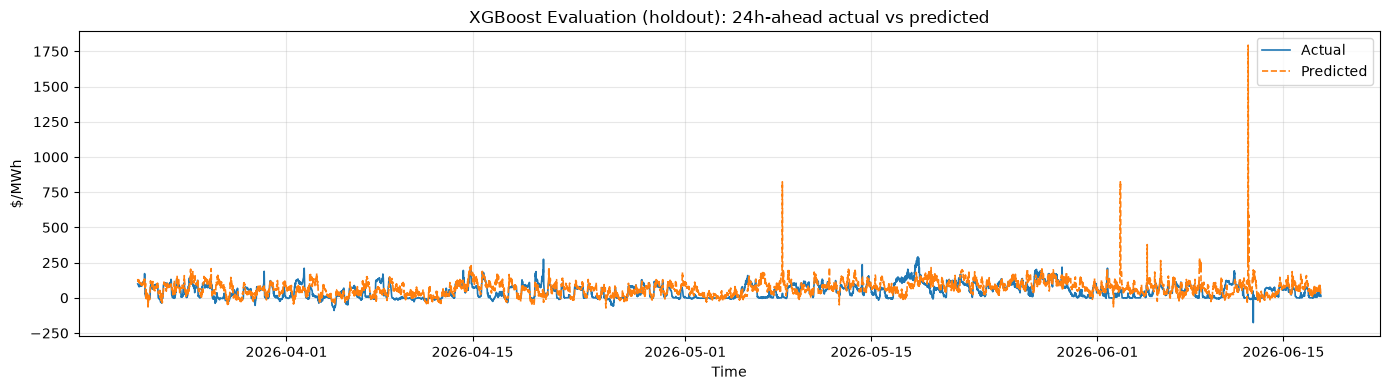

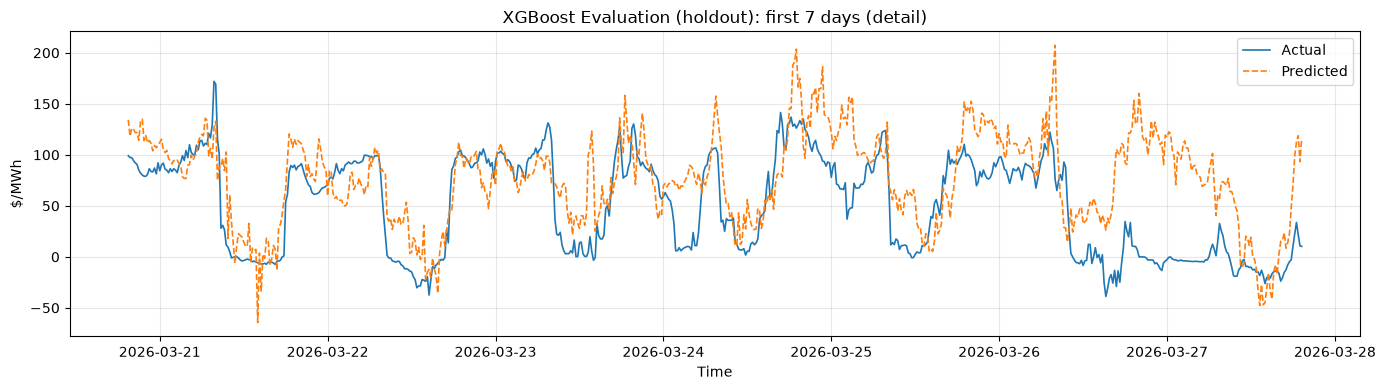

In [6]:
# Tabular direct multi-step baseline (XGBoost if installed, else sklearn HGBR)
from sklearn.metrics import mean_absolute_error

from evaluation.plotting import plot_actual_vs_predicted_timeseries

try:
    from xgboost import XGBRegressor

    def make_tabular_model():
        return XGBRegressor(max_depth=6, n_estimators=100, random_state=42)

    model_name = "XGBoost"
except ImportError:
    from sklearn.ensemble import HistGradientBoostingRegressor

    def make_tabular_model():
        return HistGradientBoostingRegressor(max_depth=6, max_iter=100, random_state=42)

    model_name = "HistGradientBoosting"

feature_cols = [
    c
    for c in df.columns
    if c not in {target_col, "timestamp"}
    and pd.api.types.is_numeric_dtype(df[c])
]

work = df.dropna(subset=[target_col]).copy()
holdout_start = work["timestamp"].max() - pd.Timedelta(days=cfg.walk_forward.holdout_days)
is_train = work["timestamp"] < holdout_start
is_eval = work["timestamp"] >= holdout_start

horizon_maes = []

for h in range(1, cfg.forecast_steps + 1):
    shifted = work[target_col].shift(-h)
    train_mask = shifted.notna() & is_train
    eval_mask = shifted.notna() & is_eval

    X_train = work.loc[train_mask, feature_cols]
    y_train = shifted.loc[train_mask]
    X_eval = work.loc[eval_mask, feature_cols]
    y_eval = shifted.loc[eval_mask]

    model = make_tabular_model()
    model.fit(X_train, y_train)
    y_hat_eval = model.predict(X_eval)
    horizon_maes.append(mean_absolute_error(y_eval, y_hat_eval))

print(f"{model_name} mean evaluation horizon MAE: {np.mean(horizon_maes):.2f} $/MWh")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, cfg.forecast_steps + 1), horizon_maes)
ax.set_title(f"{model_name} per-horizon evaluation MAE")
ax.set_xlabel("Horizon step")
ax.set_ylabel("MAE ($/MWh)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Time series at 24h-ahead horizon (indexed by target timestamp)
ts_horizon = cfg.forecast_steps
lead = pd.Timedelta(minutes=cfg.interval_minutes * ts_horizon)
shifted = work[target_col].shift(-ts_horizon)
train_mask = shifted.notna() & is_train
eval_mask = shifted.notna() & is_eval

model = make_tabular_model()
model.fit(work.loc[train_mask, feature_cols], shifted.loc[train_mask])

train_ts = pd.DataFrame(
    {
        "timestamp": work.loc[train_mask, "timestamp"].to_numpy() + lead,
        "actual": shifted.loc[train_mask].to_numpy(),
        "predicted": model.predict(work.loc[train_mask, feature_cols]),
    }
).sort_values("timestamp")

eval_ts = pd.DataFrame(
    {
        "timestamp": work.loc[eval_mask, "timestamp"].to_numpy() + lead,
        "actual": shifted.loc[eval_mask].to_numpy(),
        "predicted": model.predict(work.loc[eval_mask, feature_cols]),
    }
).sort_values("timestamp")

for split_name, ts_df in (("Training", train_ts), ("Evaluation (holdout)", eval_ts)):
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_actual_vs_predicted_timeseries(
        ts_df,
        model_name=model_name,
        title=f"{model_name} {split_name}: 24h-ahead actual vs predicted",
        ax=ax,
    )
    plt.tight_layout()
    plt.show()

    week = ts_df.iloc[: 96 * 7]
    fig, ax = plt.subplots(figsize=(14, 4))
    plot_actual_vs_predicted_timeseries(
        week,
        model_name=model_name,
        title=f"{model_name} {split_name}: first 7 days (detail)",
        ax=ax,
    )
    plt.tight_layout()
    plt.show()